In [1]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict ,Annotated , Literal
from pydantic import BaseModel , Field
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import operator

c:\Users\Mushaf\Desktop\GenAI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [4]:
class SentimentSchema(BaseModel):
    sentiment : Literal["positive" , "negative"] = Field(description="Sentiments of the review")

In [11]:
class DiagnosisSchema(BaseModel):
    issueType : Literal["UX" , "Performance" , "Bug" ,"Support" , "Other"] = Field(description="The issue customer is facing")
    tone : Literal["angry" , "dissapointed" , "frustuated" ,"calm" , "Happy"] = Field(description="The tone of customer")
    urgency : Literal["Low" , "Medium" , "High"] = Field(description="How urgent or critical the issue is")
    

In [12]:
structuredModel2 = model.with_structured_output(DiagnosisSchema)
structuredModel = model.with_structured_output(SentimentSchema)

In [7]:
prompt = "The vase orderd from your plateform waws deliverd broken"
structuredModel.invoke(prompt)

SentimentSchema(sentiment='negative')

In [6]:
class ReviewState(TypedDict):
    review : str
    sentiment : Literal["positive" , "negaive"]
    diagnosis: dict
    response: str

In [ ]:
def findSentiment(state: ReviewState):
    prompt = f"find the sentiment of the review  {state['review']}"
    sentiment = structuredModel.invoke(prompt)
    return {"sentiment" : sentiment}


def checkSentiments(state: ReviewState)-> Literal["positiveResponse" , "runDiagnosis"]:
    if state["sentiment"] == "positive":
        return "positiveResponse"
    else:
        return "runDiagnosis"
        
        
def positiveResponse(state: ReviewState):
    prompt = f"Write a warm reply for the review \n {state['review']} "
    response = model.invoke(prompt)
    return {"response" , response}

def runDiagnosis(state: ReviewState):
    prompt = f"Diagnose this negative review {state['review']} and  Return issueType , Urgency and Tone"
    response = structuredModel2.invoke(prompt)
    return {"diagnosis" , response.modelDump()}

 
def negativeResponse(state: ReviewState):
    diagnosis = state["diagnosis"]
    prompt = f"you are a support assistant user have a {diagnosis["issueType"]} issue and tone in review is {diagnosis["tone"]} and urgency is {diagnosis["urgency"]} write a feedback for the negative review"
    
    response = model.invoke(prompt)
    
    return {"response" , response}
    
         

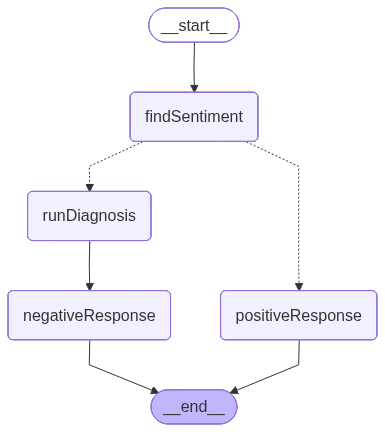

In [30]:
graph = StateGraph(ReviewState)

graph.add_node("findSentiment", findSentiment)
graph.add_node("positiveResponse", positiveResponse)
graph.add_node("runDiagnosis", runDiagnosis)
graph.add_node("negativeResponse", negativeResponse)

graph.add_edge(START, "findSentiment")

graph.add_conditional_edges(
    "findSentiment",
    checkSentiments,
    {
        "positiveResponse": "positiveResponse",
        "runDiagnosis": "runDiagnosis",
    },
)

graph.add_edge("positiveResponse", END)
graph.add_edge("runDiagnosis", "negativeResponse")
graph.add_edge("negativeResponse", END)

graph.compile()


In [31]:
workflow = graph.compile()
initialState = {"review" : "The quality of the vase was good but unfortuantility it was delivered to my broken by a scum"}
finalState = workflow.invoke(initialState)


KeyError: 'diagnosis'

In [ ]:
finalState